# EDA: `achievements`

**Descripción:** Logros (achievements) disponibles en cada juego de Steam.

| Columna | Tipo | Descripción |
|---|---|---|
| `achievementid` | str | ID único: `gameID_achievementCode` |
| `gameid` | float | ID del juego al que pertenece el logro |
| `title` | str | Nombre del logro |
| `description` | str | Descripción de cómo desbloquear el logro |

---

##  Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

DARK_BG = '#0e1117'
CARD_BG = '#1a1f2e'
ACCENT1 = '#4f86f7'
ACCENT2 = '#7ee8a2'
ACCENT3 = '#ff6b6b'
ACCENT4 = '#ffd166'
TEXT    = '#e0e6f0'
MUTED   = '#8892a4'

plt.rcParams.update({
    'figure.facecolor': DARK_BG, 'axes.facecolor': CARD_BG,
    'axes.edgecolor': MUTED,     'axes.labelcolor': TEXT,
    'xtick.color': MUTED,        'ytick.color': MUTED,
    'text.color': TEXT,          'grid.color': '#2d3348',
    'grid.alpha': 0.6,           'font.family': 'DejaVu Sans',
    'font.size': 11,
})

def title_ax(ax, txt, sub=None):
    ax.set_title(txt, fontsize=13, fontweight='bold', color=TEXT, pad=8)
    if sub:
        ax.text(0.5, 1.02, sub, transform=ax.transAxes,
                ha='center', fontsize=9, color=MUTED)

##  Carga y exploración inicial

In [2]:
df_raw = pd.read_csv('Datos/achievements.csv') 
print(f"Shape: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
df_raw.head(5)

Shape: 1,939,027 filas × 4 columnas


,achievementid,gameid,title,description
0,2621440_ACH_FIRST_KILL,2621440,FIRST KILL,You should kill ONE enemy.
1,2621440_ACH_0_LEVEL_COMPLETED,2621440,TUTORIAL COMPLETED,You should complete tutorial.
2,2621440_ACH_1_LEVEL_COMPLETED,2621440,FIRST LEVEL,You should complete first level
3,2621440_ACH_2_LEVEL_COMPLETED,2621440,SECOND LEVEL,You should complete second level
4,2621440_ACH_3_LEVEL_COMPLETED,2621440,THIRD LEVEL,You should complete third level


In [3]:
print(df_raw.dtypes)
print()
df_raw.describe(include='all')

achievementid    object
gameid            int64
title            object
description      object
dtype: object



,achievementid,gameid,title,description
count,1939027,1.939027e+06,1934556,1766815
unique,1939027,NaN,983204,1063798
top,2621440_ACH_FIRST_KILL,NaN,Super Trivia Champion,Super Trivia Champion
freq,1,NaN,148999,148999
mean,NaN,1.194505e+06,NaN,NaN
std,NaN,7.509441e+05,NaN,NaN
min,NaN,2.200000e+02,NaN,NaN
25%,NaN,6.902400e+05,NaN,NaN
50%,NaN,8.570600e+05,NaN,NaN
75%,NaN,1.655550e+06,NaN,NaN


---
##  Análisis y tratamiento de valores faltantes

### Razonamiento
- Un logro sin `title` no tiene nombre visible en Steam es un registro corrupto o placeholder. Al ser <0.1%, se elimina sin pérdida significativa.
- La `description` vacía es un patrón habitual en Steam: muchos desarrolladores registran logros sin texto explicativo. Imputar con `'No description'` preserva el registro y permite análisis de texto posteriores sin errores.

In [4]:
missing = df_raw.isnull() | (df_raw.apply(lambda col: col.astype(str).str.strip() == ''))
miss_pct = (missing.mean() * 100).round(2)
miss_cnt = missing.sum()

print("Faltantes por columna:")
pd.DataFrame({'count': miss_cnt, 'pct (%)': miss_pct}).sort_values('pct (%)', ascending=False)

Faltantes por columna:


,count,pct (%)
description,177487,9.15
title,5224,0.27
gameid,0,0.00
achievementid,0,0.00


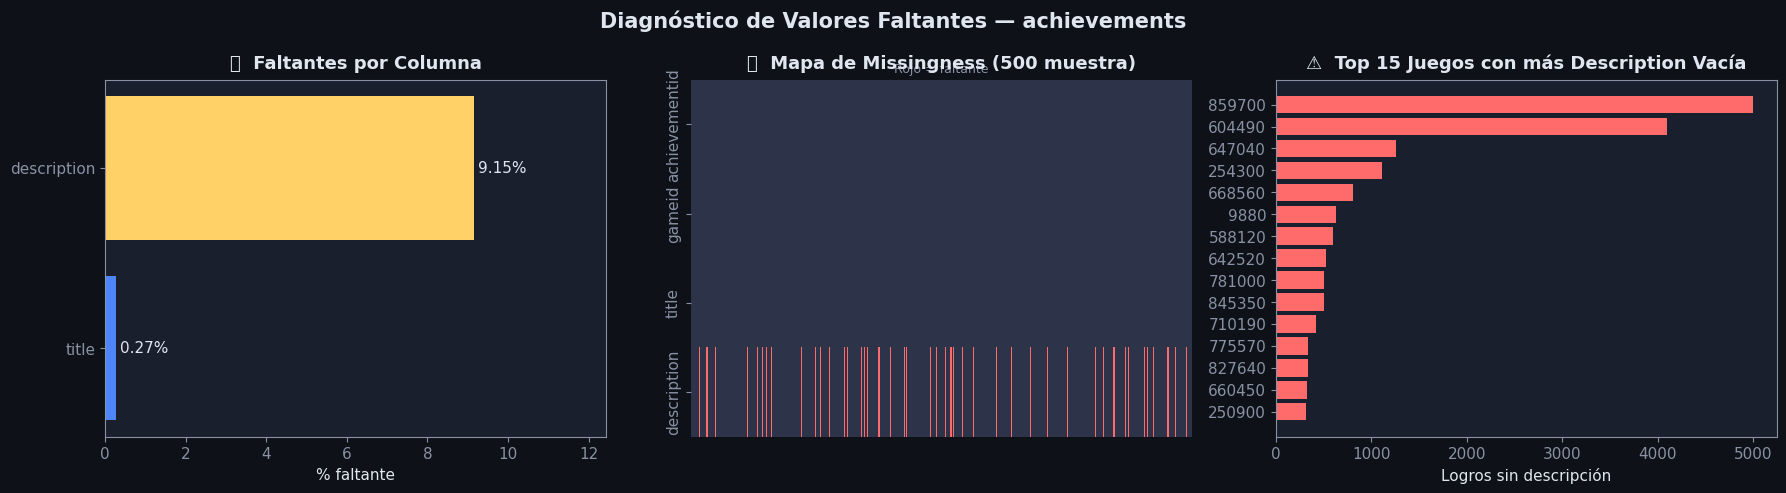

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Diagnóstico de Valores Faltantes — achievements', fontsize=15,
             fontweight='bold', color=TEXT)

ax = axes[0]
cols_m = miss_pct[miss_pct > 0].sort_values()
colors_m = [ACCENT3 if v > 30 else ACCENT4 if v > 5 else ACCENT1 for v in cols_m.values]
bars = ax.barh(cols_m.index, cols_m.values, color=colors_m)
for bar, val in zip(bars, cols_m.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', color=TEXT, fontsize=11)
ax.set_xlim(0, max(cols_m.values) * 1.25 + 1)
ax.set_xlabel('% faltante')
title_ax(ax, '🔍  Faltantes por Columna')

ax = axes[1]
sample = df_raw.sample(min(500, len(df_raw)), random_state=42)
miss_m = sample.isnull() | (sample.apply(lambda col: col.astype(str).str.strip() == ''))
sns.heatmap(miss_m.T, ax=ax, cbar=False,
            cmap=['#2d3348', ACCENT3], yticklabels=True, xticklabels=False)
title_ax(ax, '🗺️  Mapa de Missingness (500 muestra)', 'Rojo = faltante')

ax = axes[2]
desc_missing = df_raw[df_raw['description'].isnull() | (df_raw['description'].str.strip() == '')]
games_with_missing = desc_missing.groupby('gameid').size().sort_values(ascending=False)
top_missing = games_with_missing.head(15)
ax.barh(top_missing.index.astype(str)[::-1], top_missing.values[::-1], color=ACCENT3)
ax.set_xlabel('Logros sin descripción')
title_ax(ax, '⚠️  Top 15 Juegos con más Description Vacía')

plt.tight_layout()
plt.show()

In [6]:
df = df_raw.copy()

before = len(df)
df = df[df['title'].notna() & (df['title'].str.strip() != '')].reset_index(drop=True)
print(f"Eliminadas por title vacío: {before - len(df):,} filas")

mask_desc = df['description'].isna() | (df['description'].str.strip() == '')
df['description'] = df['description'].fillna('No description')
df.loc[df['description'].str.strip() == '', 'description'] = 'No description'
print(f"Description imputada: {mask_desc.sum():,} filas → 'No description'")

df['gameid'] = df['gameid'].astype(int)

GENERIC_TITLES = [
    'an achievement.', 'community achievement',
    'this is an achievement.', 'achievement'
]
df['is_generic'] = df['title'].str.lower().str.strip().isin(GENERIC_TITLES)

print(f"\nDataset final: {len(df):,} filas")
print(f"Faltantes restantes: {df.isnull().sum().sum()}")
df.head(3)

Eliminadas por title vacío: 5,224 filas
Description imputada: 173,173 filas → 'No description'

Dataset final: 1,933,803 filas
Faltantes restantes: 0


,achievementid,gameid,title,description,is_generic
0,2621440_ACH_FIRST_KILL,2621440,FIRST KILL,You should kill ONE enemy.,False
1,2621440_ACH_0_LEVEL_COMPLETED,2621440,TUTORIAL COMPLETED,You should complete tutorial.,False
2,2621440_ACH_1_LEVEL_COMPLETED,2621440,FIRST LEVEL,You should complete first level,False


---
## Estructura del `achievementid` y validación de integridad

- El campo `achievementid` sigue el patrón `{gameid}_{codigo}`, lo que permite extraer el `gameid` directamente del ID y **validar consistencia** con la columna `gameid`.
- **No hay `achievementid` duplicados**, lo que confirma que es una clave primaria confiable.
- El código del logro (sufijo) tiene alta variabilidad: algunos juegos usan nombres descriptivos (`ACH_FIRST_KILL`), otros usan índices numéricos (`ACH_00001`).

In [7]:
df['ach_gameid_prefix'] = df['achievementid'].str.split('_').str[0]
df['ach_code']          = df['achievementid'].str.split('_', n=1).str[1]

mismatch = df[df['ach_gameid_prefix'] != df['gameid'].astype(str)]
print(f"achievementid con prefijo != gameid : {len(mismatch):,}")
print(f"achievementid duplicados            : {df['achievementid'].duplicated().sum():,}")
print(f"Juegos únicos                       : {df['gameid'].nunique():,}")
print(f"Logros totales                      : {len(df):,}")

if len(mismatch) > 0:
    print("\nRegistros con mismatch:")
    print(mismatch[['achievementid', 'gameid', 'title']].head())

achievementid con prefijo != gameid : 0
achievementid duplicados            : 0
Juegos únicos                       : 50,540
Logros totales                      : 1,933,803


## Distribución de Logros por Juego

###  Hallazgos

- La distribución es **fuertemente sesgada a la derecha**: la mediana es **18 logros por juego**, mientras que el promedio es **38**, lo que indica que unos pocos juegos con muchos logros elevan la media.

- El **75% de los juegos tiene 32 logros o menos**, lo que representa un diseño de logros razonable y consistente con la mayoría de juegos comerciales.

- Existe una **cola larga** hacia valores altos: el **1% superior supera los 152 logros**, mostrando que algunos juegos incluyen sistemas de logros muy extensos.

- Se detectan **77 juegos con exactamente 5,000 logros**, un valor sospechoso porque **5,000 es el límite impuesto por Steam**. Alcanzar ese límite exacto suele asociarse con prácticas de *achievement spam*, donde se generan miles de logros triviales para inflar el conteo visible en el perfil del jugador.

- El valor máximo observado es **10,979 logros**, muy por encima del límite estándar. Esto sugiere posibles **errores de datos, agregación de múltiples versiones del juego o inconsistencias en el scraping del dataset**.

- También existe una **cola de juegos con muy pocos logros**: **1,241 juegos tienen solo 1 logro**, típicamente demos, juegos muy pequeños o títulos experimentales.



In [8]:
per_game = df.groupby('gameid').size().rename('n_achievements')

print("Estadísticas de logros por juego:")
print(per_game.describe(percentiles=[.25, .5, .75, .90, .95, .99]))
print(f"\nJuegos con exactamente 5,000 logros (spam): {(per_game == 5000).sum():,}")
print(f"Juegos con 1 solo logro                   : {(per_game == 1).sum():,}")

Estadísticas de logros por juego:
count    50540.000000
mean        38.262822
std        230.239123
min          1.000000
25%         10.000000
50%         18.000000
75%         32.000000
90%         54.000000
95%         80.000000
99%        152.000000
max      10979.000000
Name: n_achievements, dtype: float64

Juegos con exactamente 5,000 logros (spam): 77
Juegos con 1 solo logro                   : 1,241


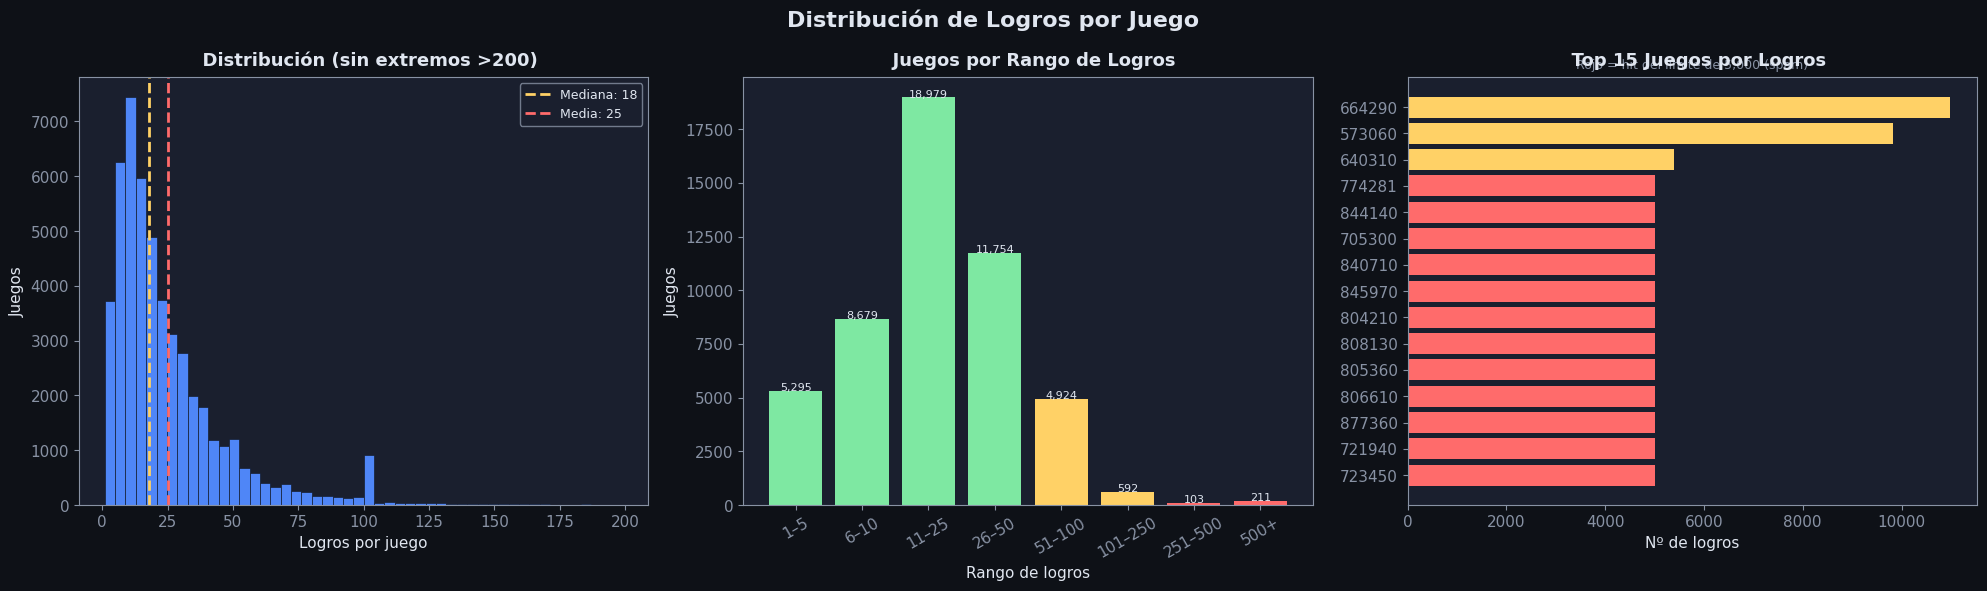

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Distribución de Logros por Juego', fontsize=16, fontweight='bold', color=TEXT)

ax = axes[0]
cap = per_game[per_game < 200]
ax.hist(cap, bins=50, color=ACCENT1, edgecolor=DARK_BG, linewidth=0.4)
ax.axvline(cap.median(), color=ACCENT4, linewidth=2, linestyle='--',
           label=f'Mediana: {cap.median():.0f}')
ax.axvline(cap.mean(), color=ACCENT3, linewidth=2, linestyle='--',
           label=f'Media: {cap.mean():.0f}')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Logros por juego'); ax.set_ylabel('Juegos')
title_ax(ax, '  Distribución (sin extremos >200)')

ax = axes[1]
bins   = [0, 5, 10, 25, 50, 100, 250, 500, 5001]
labels = ['1–5','6–10','11–25','26–50','51–100','101–250','251–500','500+']
pg_df = per_game.reset_index()
pg_df['bucket'] = pd.cut(pg_df['n_achievements'], bins=bins, labels=labels)
bucket_counts = pg_df['bucket'].value_counts().sort_index()
colors_b = [ACCENT2 if i < 4 else ACCENT4 if i < 6 else ACCENT3 for i in range(len(bucket_counts))]
ax.bar(bucket_counts.index.astype(str), bucket_counts.values, color=colors_b)
for i, v in enumerate(bucket_counts.values):
    ax.text(i, v + 20, f'{v:,}', ha='center', fontsize=8, color=TEXT)
ax.set_xlabel('Rango de logros'); ax.set_ylabel('Juegos')
ax.tick_params(axis='x', rotation=30)
title_ax(ax, '  Juegos por Rango de Logros')

ax = axes[2]
top15 = per_game.sort_values(ascending=False).head(15)
colors_t = [ACCENT3 if v == 5000 else ACCENT4 for v in top15.values]
ax.barh(top15.index.astype(str)[::-1], top15.values[::-1], color=colors_t[::-1])
ax.set_xlabel('Nº de logros')
title_ax(ax, '  Top 15 Juegos por Logros', 'Rojo = hit del límite de 5,000 (spam)')

plt.tight_layout()
plt.show()

---
##  Outliers: Juegos con Cantidad Extrema de Logros


La sección anterior reveló que el **máximo de logros por juego supera los 10,000**, y que Steam impone un límite oficial de **5,000**. Esto significa que los valores más extremos son **anomalías reales** registros que exceden incluso las prácticas de spam convencional.

### Enfoque del análisis
Se utilizan **dos métodos complementarios** para detectar outliers:
- **IQR (Rango Intercuartílico):** método robusto, no sensible a la cola extrema. Umbral = Q3 + 1.5 × IQR.
- **Percentil 99:** criterio práctico para separar el 1% superior del universo de juegos.

Además, se segmentan los outliers en tres categorías:
1. **> 5,000 logros** → Viola el límite oficial de Steam. Probablemente errores de ingesta o duplicados.
2. **= 5,000 logros** → Tope exacto. Casi siempre achievement spam deliberado.
3. **Outlier IQR pero < 5,000** → Casos elevados pero posiblemente legítimos (franquicias grandes, DLC incluidos).

In [10]:
per_game = df.groupby('gameid').size().rename('n_achievements')

Q1, Q3 = per_game.quantile(0.25), per_game.quantile(0.75)
IQR    = Q3 - Q1
iqr_upper = Q3 + 1.5 * IQR
p99        = per_game.quantile(0.99)


mask_above_5k  = per_game > 5000          
mask_exact_5k  = per_game == 5000         
mask_iqr_out   = (per_game > iqr_upper) & (per_game < 5000)  
mask_normal    = per_game <= iqr_upper

print(f"Q1={Q1:.0f}  Q3={Q3:.0f}  IQR={IQR:.0f}")
print(f"Umbral IQR (Q3 + 1.5×IQR) : {iqr_upper:.0f} logros")
print(f"Percentil 99               : {p99:.0f} logros")
print(f"Máximo observado           : {per_game.max():,} logros")
print()
print(f"Juegos con > 5,000 logros (inválidos)  : {mask_above_5k.sum():,}")
print(f"Juegos con = 5,000 logros (spam tope)  : {mask_exact_5k.sum():,}")
print(f"Outliers IQR moderados (< 5,000)       : {mask_iqr_out.sum():,}")
print(f"Juegos dentro del rango normal         : {mask_normal.sum():,}")
print()
print("Top 20 juegos con más logros:")
per_game.sort_values(ascending=False).head(20).to_frame().assign(
    categoria=lambda x: x['n_achievements'].map(
        lambda v: '🔴 Inválido (>5k)' if v > 5000 else
                  '🟠 Spam tope (5k)' if v == 5000 else
                  '🟡 Outlier IQR' if v > iqr_upper else '🟢 Normal'
    )
)

Q1=10  Q3=32  IQR=22
Umbral IQR (Q3 + 1.5×IQR) : 65 logros
Percentil 99               : 152 logros
Máximo observado           : 10,979 logros

Juegos con > 5,000 logros (inválidos)  : 3
Juegos con = 5,000 logros (spam tope)  : 77
Outliers IQR moderados (< 5,000)       : 3,556
Juegos dentro del rango normal         : 46,904

Top 20 juegos con más logros:


,n_achievements,categoria
gameid,,
664290,10979,🔴 Inválido (>5k)
573060,9821,🔴 Inválido (>5k)
640310,5394,🔴 Inválido (>5k)
774281,5000,🟠 Spam tope (5k)
844140,5000,🟠 Spam tope (5k)
705300,5000,🟠 Spam tope (5k)
840710,5000,🟠 Spam tope (5k)
845970,5000,🟠 Spam tope (5k)
804210,5000,🟠 Spam tope (5k)


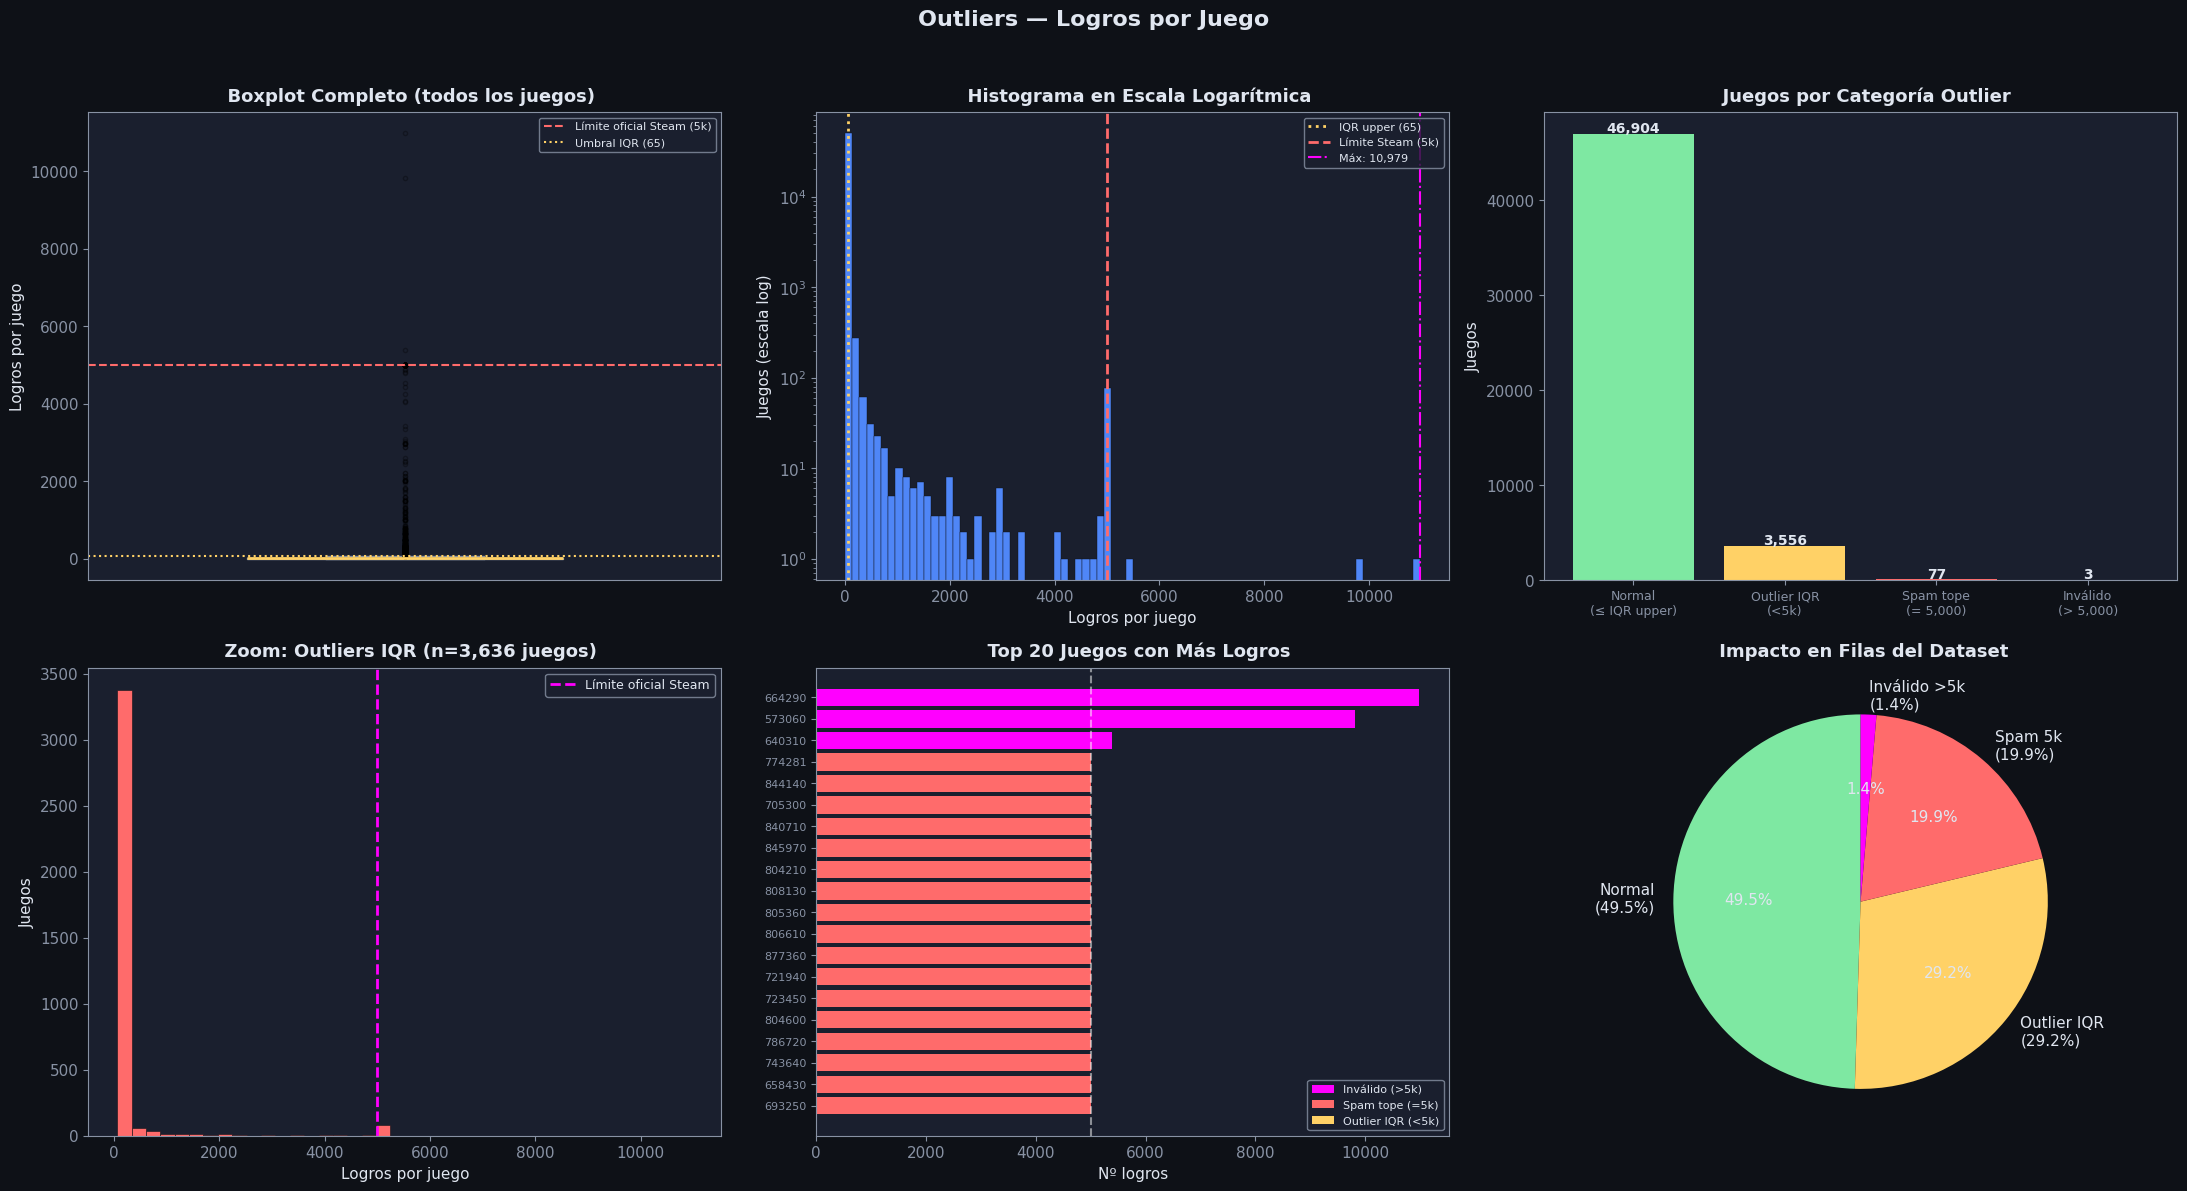

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Outliers — Logros por Juego', fontsize=16, fontweight='bold', color=TEXT, y=0.99)

ax = axes[0, 0]
bp = ax.boxplot(per_game.values, vert=True, patch_artist=True, widths=0.5,
                boxprops=dict(facecolor=ACCENT1, color=MUTED),
                medianprops=dict(color=ACCENT4, linewidth=2),
                whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
                flierprops=dict(marker='o', color=ACCENT3, alpha=0.3, markersize=3))
ax.axhline(5000, color=ACCENT3, linestyle='--', linewidth=1.5, label='Límite oficial Steam (5k)')
ax.axhline(iqr_upper, color=ACCENT4, linestyle=':', linewidth=1.5, label=f'Umbral IQR ({iqr_upper:.0f})')
ax.legend(fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_ylabel('Logros por juego')
ax.set_xticks([])
title_ax(ax, '  Boxplot Completo (todos los juegos)')

ax = axes[0, 1]
ax.hist(per_game.values, bins=80, color=ACCENT1, edgecolor=DARK_BG, linewidth=0.3, log=True)
ax.axvline(iqr_upper, color=ACCENT4, linewidth=2, linestyle=':', label=f'IQR upper ({iqr_upper:.0f})')
ax.axvline(5000,      color=ACCENT3, linewidth=2, linestyle='--', label='Límite Steam (5k)')
ax.axvline(per_game.max(), color='#ff00ff', linewidth=1.5, linestyle='-.',
           label=f'Máx: {per_game.max():,}')
ax.legend(fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Logros por juego'); ax.set_ylabel('Juegos (escala log)')
title_ax(ax, '  Histograma en Escala Logarítmica')

ax = axes[0, 2]
cats = {
    'Normal\n(≤ IQR upper)':     mask_normal.sum(),
    f'Outlier IQR\n(<5k)':       mask_iqr_out.sum(),
    'Spam tope\n(= 5,000)':      mask_exact_5k.sum(),
    'Inválido\n(> 5,000)':       mask_above_5k.sum(),
}
bar_colors = [ACCENT2, ACCENT4, ACCENT3, '#ff00ff']
bars = ax.bar(list(cats.keys()), list(cats.values()), color=bar_colors)
for bar, val in zip(bars, cats.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + per_game.shape[0]*0.003,
            f'{val:,}', ha='center', fontsize=10, color=TEXT, fontweight='bold')
ax.set_ylabel('Juegos')
ax.tick_params(axis='x', labelsize=9)
title_ax(ax, '  Juegos por Categoría Outlier')


ax = axes[1, 0]
outliers_only = per_game[per_game > iqr_upper]
ax.hist(outliers_only.values, bins=40, color=ACCENT3, edgecolor=DARK_BG, linewidth=0.4)
ax.axvline(5000, color='#ff00ff', linewidth=2, linestyle='--', label='Límite oficial Steam')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Logros por juego'); ax.set_ylabel('Juegos')
title_ax(ax, f'  Zoom: Outliers IQR (n={len(outliers_only):,} juegos)')


ax = axes[1, 1]
top20 = per_game.sort_values(ascending=False).head(20)
c_top = ['#ff00ff' if v > 5000 else ACCENT3 if v == 5000 else ACCENT4 for v in top20.values]
ax.barh(range(len(top20)), top20.values[::-1], color=c_top[::-1])
ax.set_yticks(range(len(top20)))
ax.set_yticklabels([str(g) for g in top20.index[::-1]], fontsize=8)
ax.axvline(5000, color='white', linewidth=1.5, linestyle='--', alpha=0.5)
ax.set_xlabel('Nº logros')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#ff00ff', label='Inválido (>5k)'),
    Patch(facecolor=ACCENT3,   label='Spam tope (=5k)'),
    Patch(facecolor=ACCENT4,   label='Outlier IQR (<5k)'),
]
ax.legend(handles=legend_elements, fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
title_ax(ax, '  Top 20 Juegos con Más Logros')


ax = axes[1, 2]
rows_normal  = df[df['gameid'].isin(per_game[mask_normal].index)].shape[0]
rows_iqr_out = df[df['gameid'].isin(per_game[mask_iqr_out].index)].shape[0]
rows_spam5k  = df[df['gameid'].isin(per_game[mask_exact_5k].index)].shape[0]
rows_inv     = df[df['gameid'].isin(per_game[mask_above_5k].index)].shape[0]
total        = len(df)
wedge_sizes  = [rows_normal, rows_iqr_out, rows_spam5k, rows_inv]
wedge_labels = [
    f'Normal\n({rows_normal/total*100:.1f}%)',
    f'Outlier IQR\n({rows_iqr_out/total*100:.1f}%)',
    f'Spam 5k\n({rows_spam5k/total*100:.1f}%)',
    f'Inválido >5k\n({rows_inv/total*100:.1f}%)',
]
ax.pie([w for w in wedge_sizes if w > 0],
       labels=[l for l, w in zip(wedge_labels, wedge_sizes) if w > 0],
       colors=[c for c, w in zip([ACCENT2, ACCENT4, ACCENT3, '#ff00ff'], wedge_sizes) if w > 0],
       startangle=90, textprops={'color': TEXT}, autopct='%1.1f%%')
title_ax(ax, ' Impacto en Filas del Dataset')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Después de revisar personalmente estos 3 juegos con más de 5.000 logros, sí es cierto que tienen esa cantidad exhorbitante. Sin embargo, hemos decidido borrarlos para no afectar el análisis. 

In [12]:

per_game = df.groupby("gameid").size().rename("n_achievements")

Q1_o, Q3_o = per_game.quantile(0.25), per_game.quantile(0.75)
iqr_upper_o = Q3_o + 1.5 * (Q3_o - Q1_o)

def categorize_game(n):
    if n > 5000:        return "invalido"
    elif n == 5000:     return "spam_tope"
    elif n > iqr_upper_o: return "outlier_iqr"
    return "normal"

game_cat = per_game.map(categorize_game).rename("outlier_cat").reset_index()
df = df.merge(game_cat, on="gameid", how="left")


invalid_game_ids = per_game[per_game > 5000].index
df = df[~df["gameid"].isin(invalid_game_ids)].copy()

n_cat = df["outlier_cat"].value_counts()
print("outlier_cat en df:")
print(n_cat)
print(f"Df tras eliminar inválidos: {len(df):,} filas")


outlier_cat en df:
outlier_cat
normal         957413
outlier_iqr    565196
spam_tope      385000
Name: count, dtype: int64
Df tras eliminar inválidos: 1,907,609 filas


---
##  Análisis de Texto: Títulos y Descripciones


- Los **títulos de logros son muy cortos y consistentes**, con una media cercana a 15 caracteres. La mitad de los títulos se encuentra entre **9 y 21 caracteres**, lo que indica que suelen ser frases breves y directas. 
- Las **descripciones son ligeramente más largas** (media ≈ 27 caracteres) y generalmente explican la condición para desbloquear el logro, por ejemplo: *"Kill 100 enemies"* o *"Complete chapter 3"*.
- Se detectan **valores extremos** (títulos de hasta 2,196 caracteres y descripciones de 1,660), que probablemente corresponden a **errores de formato o registros atípicos**.
- Se identificaron **10,634 logros con títulos genéricos** (`0.56%` del dataset), como *"This is an achievement"* o *"Community achievement"*, los cuales aportan poca información semántica.
- Algunos títulos aparecen **decenas de miles de veces** (ej. *"Super Trivia Champion"*), lo que sugiere la presencia de **juegos con generación masiva de logros (achievement spam)**.



In [13]:
df['title_len'] = df['title'].str.len()
df['desc_len']  = df['description'].str.len()

print("Longitud de títulos:")
print(df['title_len'].describe())
print("\nLongitud de descripciones:")
print(df['desc_len'].describe())

print(f"\nLogros con título genérico (is_generic=True): {df['is_generic'].sum():,} ({df['is_generic'].mean()*100:.2f}%)")

Longitud de títulos:
count    1.907609e+06
mean     1.525122e+01
std      8.630370e+00
min      1.000000e+00
25%      9.000000e+00
50%      1.500000e+01
75%      2.100000e+01
max      2.196000e+03
Name: title_len, dtype: float64

Longitud de descripciones:
count    1.907609e+06
mean     2.672150e+01
std      1.845247e+01
min      1.000000e+00
25%      1.500000e+01
50%      2.300000e+01
75%      3.300000e+01
max      1.660000e+03
Name: desc_len, dtype: float64

Logros con título genérico (is_generic=True): 10,634 (0.56%)


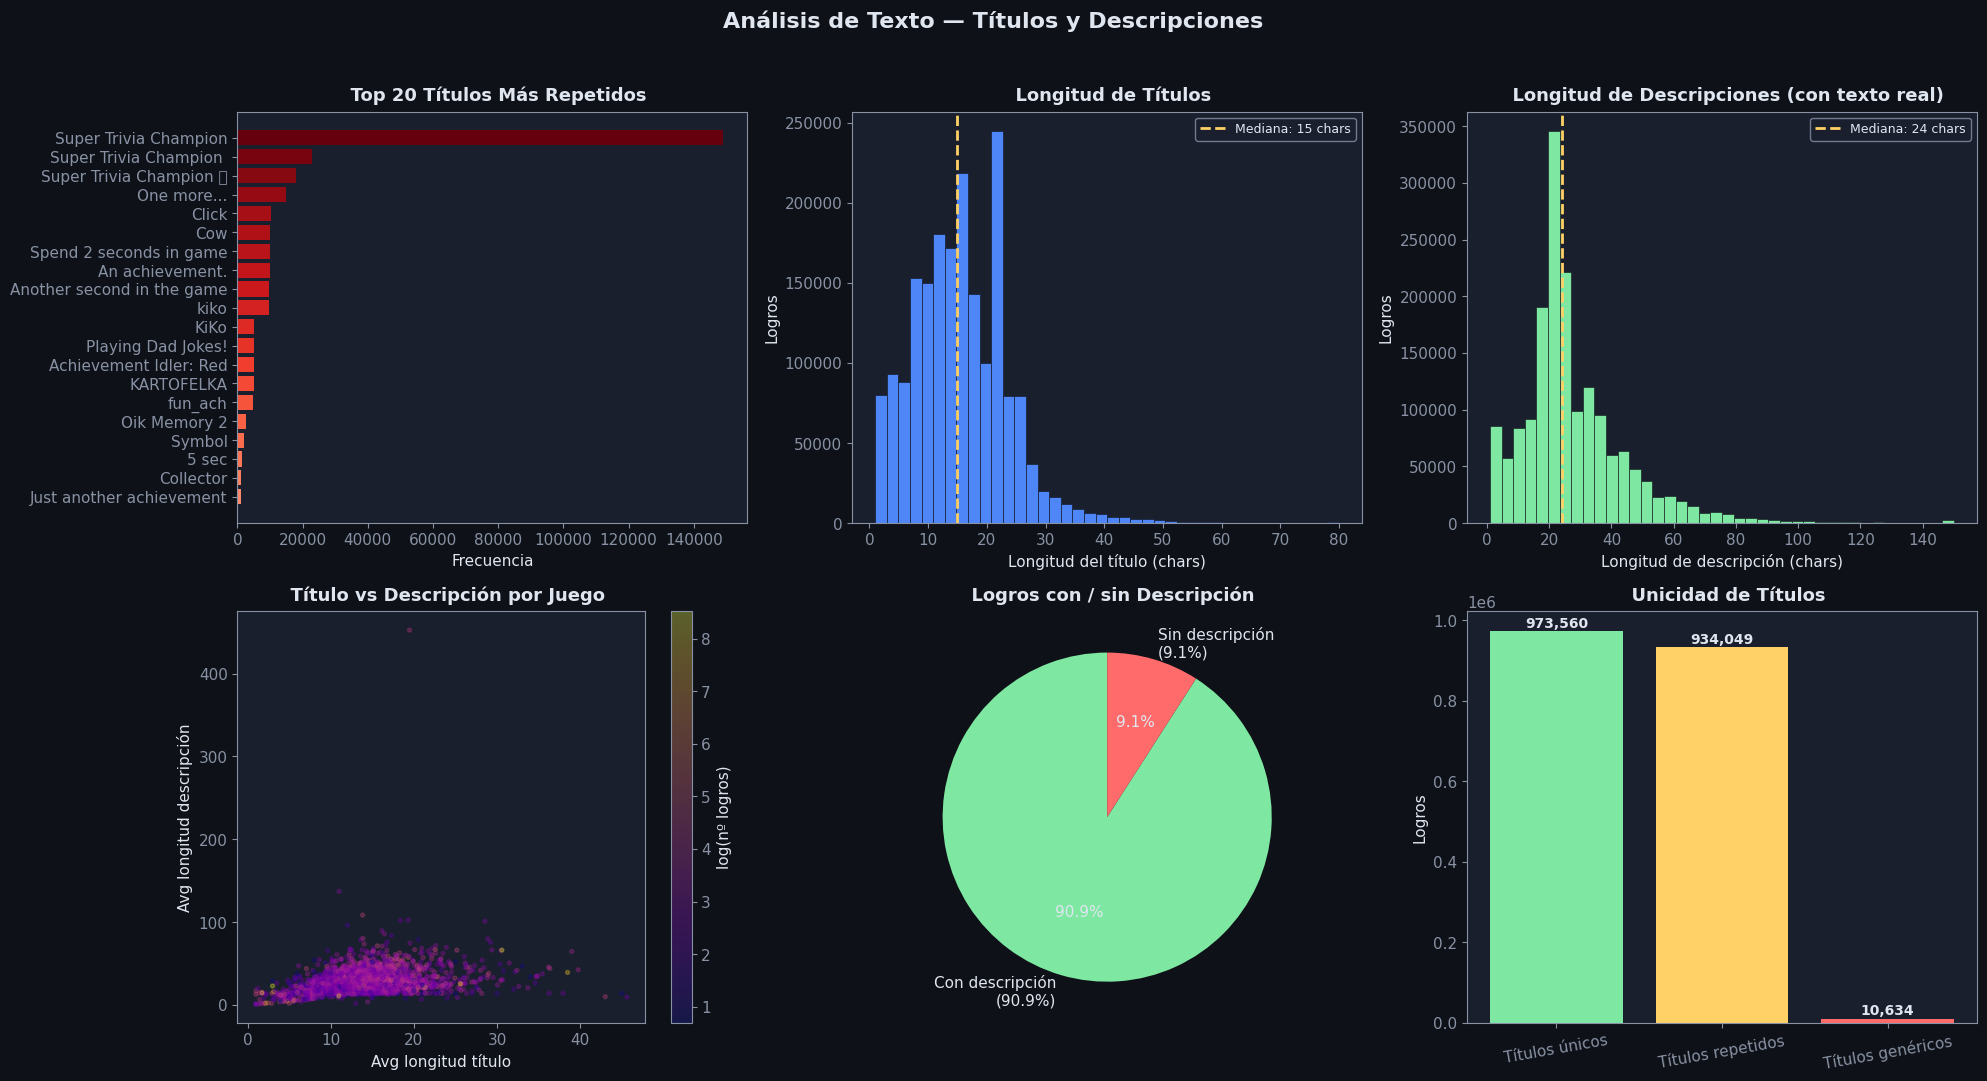

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Análisis de Texto — Títulos y Descripciones', fontsize=16, fontweight='bold', color=TEXT, y=0.98)

ax = axes[0, 0]
top_titles = df['title'].value_counts().head(20)
cmap = plt.cm.Reds(np.linspace(0.4, 1.0, len(top_titles)))
ax.barh(top_titles.index[::-1], top_titles.values[::-1], color=cmap)
ax.set_xlabel('Frecuencia')
title_ax(ax, '  Top 20 Títulos Más Repetidos')

ax = axes[0, 1]
ax.hist(df['title_len'].clip(upper=80), bins=40, color=ACCENT1,
        edgecolor=DARK_BG, linewidth=0.4)
ax.axvline(df['title_len'].median(), color=ACCENT4, linewidth=2,
           linestyle='--', label=f"Mediana: {df['title_len'].median():.0f} chars")
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Longitud del título (chars)'); ax.set_ylabel('Logros')
title_ax(ax, '  Longitud de Títulos')

ax = axes[0, 2]
no_desc = (df['description'] == 'No description').sum()
has_desc = df[df['description'] != 'No description']
ax.hist(has_desc['desc_len'].clip(upper=150), bins=40, color=ACCENT2,
        edgecolor=DARK_BG, linewidth=0.4)
ax.axvline(has_desc['desc_len'].median(), color=ACCENT4, linewidth=2,
           linestyle='--', label=f"Mediana: {has_desc['desc_len'].median():.0f} chars")
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Longitud de descripción (chars)'); ax.set_ylabel('Logros')
title_ax(ax, '  Longitud de Descripciones (con texto real)')

ax = axes[1, 0]
sample_games = df.groupby('gameid').agg(
    avg_title_len=('title_len','mean'),
    avg_desc_len=('desc_len','mean'),
    n_ach=('achievementid','count')
).sample(min(3000, df['gameid'].nunique()), random_state=42)
sc = ax.scatter(sample_games['avg_title_len'], sample_games['avg_desc_len'],
                alpha=0.3, s=8, c=np.log1p(sample_games['n_ach']), cmap='plasma')
plt.colorbar(sc, ax=ax, label='log(nº logros)')
ax.set_xlabel('Avg longitud título'); ax.set_ylabel('Avg longitud descripción')
title_ax(ax, '  Título vs Descripción por Juego')


ax = axes[1, 1]
real_desc = (df['description'] != 'No description').sum()
ax.pie([real_desc, no_desc],
       labels=[f'Con descripción\n({real_desc/len(df)*100:.1f}%)',
               f'Sin descripción\n({no_desc/len(df)*100:.1f}%)'],
       colors=[ACCENT2, ACCENT3], startangle=90,
       textprops={'color': TEXT}, autopct='%1.1f%%')
title_ax(ax, '  Logros con / sin Descripción')


ax = axes[1, 2]
unique_titles = df['title'].nunique()
total_titles  = len(df)
repeated = total_titles - unique_titles
generic_n = df['is_generic'].sum()
bars_lbl = ['Títulos únicos', 'Títulos repetidos', 'Títulos genéricos']
bars_val = [unique_titles, repeated, generic_n]
ax.bar(bars_lbl, bars_val, color=[ACCENT2, ACCENT4, ACCENT3])
for i, v in enumerate(bars_val):
    ax.text(i, v + total_titles*0.005, f'{v:,}', ha='center', fontsize=10,
            color=TEXT, fontweight='bold')
ax.set_ylabel('Logros')
ax.tick_params(axis='x', rotation=10)
title_ax(ax, '  Unicidad de Títulos')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

---
##  Detección de Achievement Spam


- Se observa **achievement spam** en algunos juegos: títulos que contienen muchos logros con **nombres repetidos o casi idénticos**, práctica asociada con inflar artificialmente los contadores de logros en Steam.
- Se define un juego como **spam** cuando **más del 80% de sus logros tienen el mismo título**.
- Con este criterio se identificaron **1,413 juegos spam (2.8%)**, que contienen **110,917 logros (5.8%)** del dataset.
- Aunque Steam tiene un **límite de 5,000 logros por juego**, solo **24.68%** de los juegos con ese número fueron detectados como spam bajo esta métrica.


In [15]:
def spam_ratio(group):
    top_freq = group['title'].value_counts().iloc[0]
    return top_freq / len(group)

game_spam = df.groupby('gameid').apply(spam_ratio).rename('spam_ratio').reset_index()
game_spam['is_spam_game'] = game_spam['spam_ratio'] > 0.8

df = df.merge(game_spam[['gameid','spam_ratio','is_spam_game']], on='gameid', how='left')

n_spam_games = game_spam['is_spam_game'].sum()
n_spam_rows  = df['is_spam_game'].sum()

print(f"Juegos marcados como spam     : {n_spam_games:,} ({n_spam_games/game_spam.shape[0]*100:.1f}% de juegos)")
print(f"Logros en juegos spam         : {n_spam_rows:,} ({n_spam_rows/len(df)*100:.1f}% de logros)")
print(f"\nDataset sin spam              : {(~df['is_spam_game']).sum():,} logros")

Juegos marcados como spam     : 1,413 (2.8% de juegos)
Logros en juegos spam         : 110,917 (5.8% de logros)

Dataset sin spam              : 1,796,692 logros


In [16]:
spam_top_games = per_game[per_game == 5000].index 

top5000 = game_spam[game_spam['gameid'].isin(spam_top_games)]

ratio_detected = top5000['is_spam_game'].mean()

print(f"Porcentaje de juegos con 5000 logros detectados como spam: {ratio_detected*100:.2f}%")

Porcentaje de juegos con 5000 logros detectados como spam: 24.68%


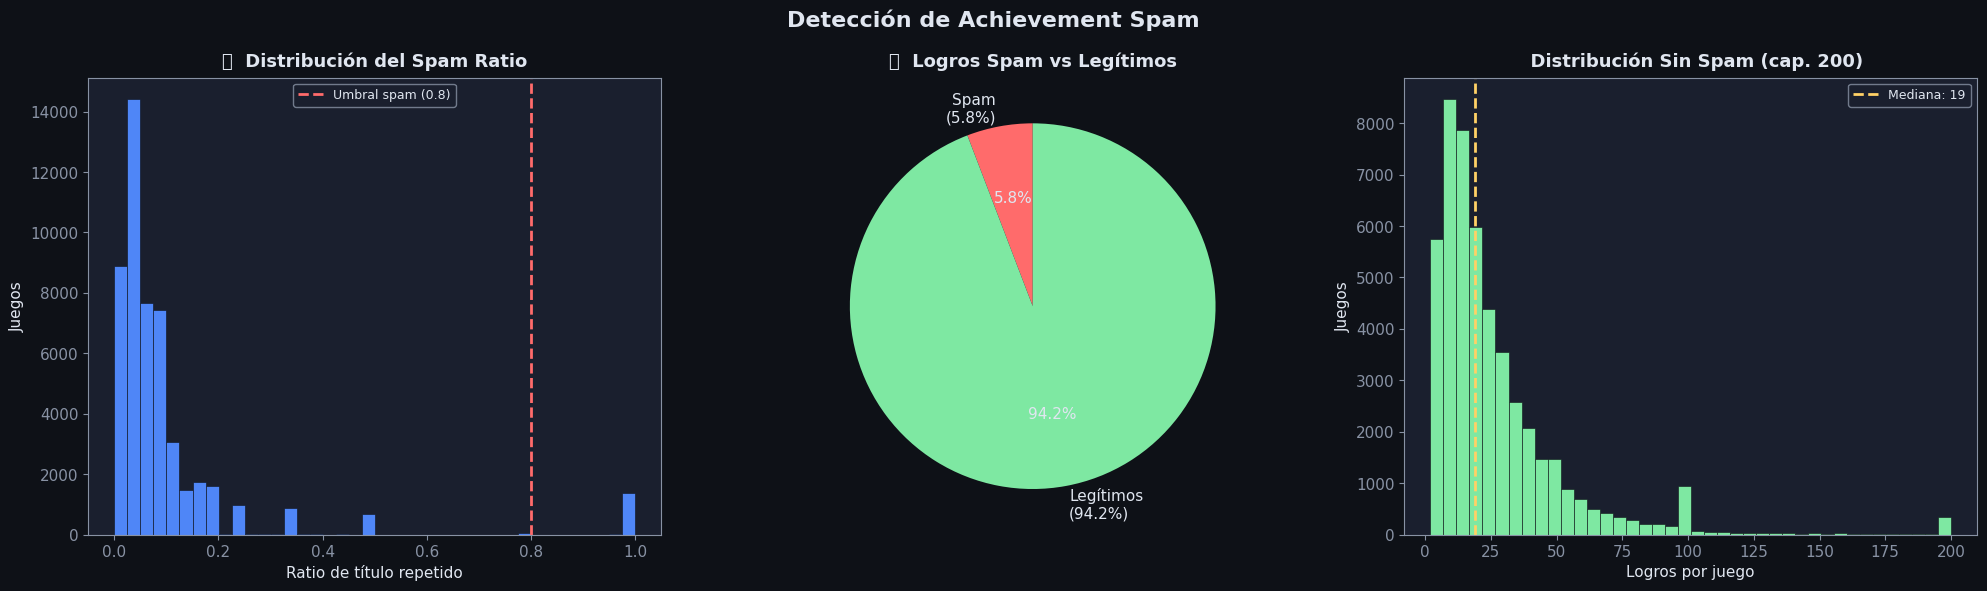

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Detección de Achievement Spam', fontsize=16, fontweight='bold', color=TEXT)

ax = axes[0]
ax.hist(game_spam['spam_ratio'], bins=40, color=ACCENT1, edgecolor=DARK_BG, linewidth=0.4)
ax.axvline(0.8, color=ACCENT3, linewidth=2, linestyle='--', label='Umbral spam (0.8)')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Ratio de título repetido'); ax.set_ylabel('Juegos')
title_ax(ax, '  Distribución del Spam Ratio')

ax = axes[1]
ax.pie([n_spam_rows, len(df) - n_spam_rows],
       labels=[f'Spam\n({n_spam_rows/len(df)*100:.1f}%)',
               f'Legítimos\n({(len(df)-n_spam_rows)/len(df)*100:.1f}%)'],
       colors=[ACCENT3, ACCENT2], startangle=90,
       textprops={'color': TEXT}, autopct='%1.1f%%')
title_ax(ax, '  Logros Spam vs Legítimos')

ax = axes[2]
clean = df[~df['is_spam_game']]
per_game_clean = clean.groupby('gameid').size()
ax.hist(per_game_clean.clip(upper=200), bins=40, color=ACCENT2,
        edgecolor=DARK_BG, linewidth=0.4)
ax.axvline(per_game_clean.median(), color=ACCENT4, linewidth=2,
           linestyle='--', label=f"Mediana: {per_game_clean.median():.0f}")
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Logros por juego'); ax.set_ylabel('Juegos')
title_ax(ax, '  Distribución Sin Spam (cap. 200)')

plt.tight_layout()
plt.show()

---
## Dataset limpio final

In [18]:
print("═" * 55)
print("  RESUMEN DEL DATASET LIMPIO — achievements")
print("═" * 55)
print(f"  Filas originales        : {df_raw.shape[0]:>10,}")
print(f"  Eliminadas (title NaN)  : {df_raw.shape[0] - len(df):>10,}")
print(f"  Filas finales           : {len(df):>10,}")
print(f"  Juegos únicos           : {df['gameid'].nunique():>10,}")
print(f"  Logros con desc real    : {(df['description']!='No description').sum():>10,}")
print(f"  Logros spam             : {df['is_spam_game'].sum():>10,}  ({df['is_spam_game'].mean()*100:.1f}%)")
print(f"  Faltantes restantes     : {df.isnull().sum().sum():>10,}")
print("═" * 55)
df.head(3)

═══════════════════════════════════════════════════════
  RESUMEN DEL DATASET LIMPIO — achievements
═══════════════════════════════════════════════════════
  Filas originales        :  1,939,027
  Eliminadas (title NaN)  :     31,418
  Filas finales           :  1,907,609
  Juegos únicos           :     50,537
  Logros con desc real    :  1,734,436
  Logros spam             :    110,917  (5.8%)
  Faltantes restantes     :          0
═══════════════════════════════════════════════════════


,achievementid,gameid,title,description,is_generic,ach_gameid_prefix,ach_code,outlier_cat,title_len,desc_len,spam_ratio,is_spam_game
0,2621440_ACH_FIRST_KILL,2621440,FIRST KILL,You should kill ONE enemy.,False,2621440,ACH_FIRST_KILL,normal,10,26,0.090909,False
1,2621440_ACH_0_LEVEL_COMPLETED,2621440,TUTORIAL COMPLETED,You should complete tutorial.,False,2621440,ACH_0_LEVEL_COMPLETED,normal,18,29,0.090909,False
2,2621440_ACH_1_LEVEL_COMPLETED,2621440,FIRST LEVEL,You should complete first level,False,2621440,ACH_1_LEVEL_COMPLETED,normal,11,31,0.090909,False


---
## Exportar dataset limpio


**Archivos generados:**
- `achievements_clean.csv` — todos los logros con flags: `is_spam_game`, `spam_ratio`, `outlier_cat`, `is_generic`
- `achievements_per_game.csv` — una fila por juego: `gameid`, `n_achievements`, `is_spam_game`, `spam_ratio`, `outlier_cat`


In [ ]:

cols_export = ['achievementid','gameid','title','description',
               'is_generic','spam_ratio','is_spam_game','outlier_cat']
df[cols_export].to_csv('Datos/achievements_clean.csv', index=False)


per_game_export = (
    df.groupby('gameid')
    .agg(
        n_achievements=('achievementid', 'count'),
        is_spam_game  =('is_spam_game',  'first'),
        spam_ratio    =('spam_ratio',     'first'),
        outlier_cat   =('outlier_cat',    'first'),
        pct_generic   =('is_generic',     'mean'),
    )
    .reset_index()
)
per_game_export.to_csv('Datos/achievements_per_game.csv', index=False)

print(f'achievements_clean.csv    : {len(df):,} filas, {len(cols_export)} columnas')
print(f'achievements_per_game.csv : {len(per_game_export):,} juegos')
per_game_export.head(3)


achievements_clean.csv    : 1,907,609 filas, 8 columnas
achievements_per_game.csv : 50,537 juegos


,gameid,n_achievements,is_spam_game,spam_ratio,outlier_cat,pct_generic
0,220,69,False,0.014493,outlier_iqr,0.0
1,240,147,False,0.006803,outlier_iqr,0.0
2,300,54,False,0.018519,normal,0.0


---
##  Conclusiones

### Próximos pasos
-  Paso obligatorio antes de cruzar con `history`: filtrar `is_spam_game = True` antes de calcular cualquier `completion_rate`. Los juegos spam distorsionan la variable objetivo del modelo de regresión — un usuario que completa un juego spam al 100% tiene 5,000 logros pero cero engagement real.
- **Cruzar con `history`** (post-filtro spam): calcular `completion_rate = logros_desbloqueados / n_logros_juego` por par `(playerid, gameid)`. Este es el target de regresión.
- **Cruzar con `games`:** enriquecer con género — ¿qué géneros tienen más logros en promedio? ¿Los juegos de ciertos géneros tienen mayor tasa de completion?
- **Columnas disponibles para feature engineering:** `n_achievements` (por juego), `is_spam_game`, `spam_ratio`, `outlier_cat`, `is_generic`.